<a href="https://colab.research.google.com/github/NastaranTork/stochastic-processes-lab/blob/main/01_poisson_processes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercise 1. Do simulated Poisson counts match the definition?

**Claim tested.** Notes 3 (Definition 5 and Proposition 3) say that a Poisson process with rate $\lambda$ has independent increments and stationary increments, and that the count $N(t)$ follows a Poisson distribution with mean $\lambda t$. I built the process from iid exponential gaps (rate $\lambda = 3$) and checked whether the resulting counts behave as the definition says.

**Prediction.** With $\lambda = 3$ and $t = 2$, the count in any window of length 2 should have mean and variance both equal to $\lambda t = 6$. Counts in non-overlapping windows should be independent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(8532)

In Poisson Process the interarrival times Xn, n = 1;2;..., are iid Exponential with mean 1/λ.

In [8]:
lam = 3
T = 10

def simulate_pp(lam, T, rng):
  arrivals = []
  clock = 0
  while True:
      gap =rng.exponential(scale=1/lam)
      clock += gap
      if clock > T:
        break
      arrivals.append(clock)
  return arrivals

a = simulate_pp(lam, T, rng)
print(len(a), a[:5], a[-1])

32 [0.1917804436209021, 0.6824958882144574, 0.7066202448395997, 0.8238442082709995, 1.1338292651598993] 9.864161396401377


In [10]:
# Helper Function
def count_in(a, lo, hi):
  count = 0
  for arr in a:
    if arr > lo and arr <= hi:
      count +=1
  return count

a = np.array([0.5, 1.2, 1.9, 3.0, 4.4])
count_in(a, 1, 3)

3

Poisson Processes Definition Test:
A counting process N(t) is a Poisson Process (PP) with rate λ> 0 if

*   N(t) has independent increments with N(0) = 0.
*   N(t) has a Poisson distribution with mean (λt) for all t ≥ 0.



In [12]:
count1 = []
count2 = []
count3 = []
for i in range(20000):
  a = simulate_pp(lam, T, rng)
  count1.append(count_in(a, 0, 2))
  count2.append(count_in(a, 4, 6))
  count3.append(count_in(a, 6, 8))

Array1 = np.array(count1)
print(np.mean(Array1), np.var(Array1))
Array2 = np.array(count2)
print(np.mean(Array2), np.var(Array2), np.corrcoef(Array1, Array2)[0, 1])
Array3 = np.array(count3)
print(np.mean(Array3), np.var(Array3))



6.0042 6.04588236
5.996 5.943784 -0.01008124653989819
6.0032 5.98968976


In [18]:
# The simulated probability
counts = np.bincount(Array1)
sim_prob = counts / len(Array1)
print(sim_prob.sum())

# The theoritical probability
k = np.arange(0, len(sim_prob))
theory = stats.poisson.pmf(k, lam * 2)

0.9999999999999999


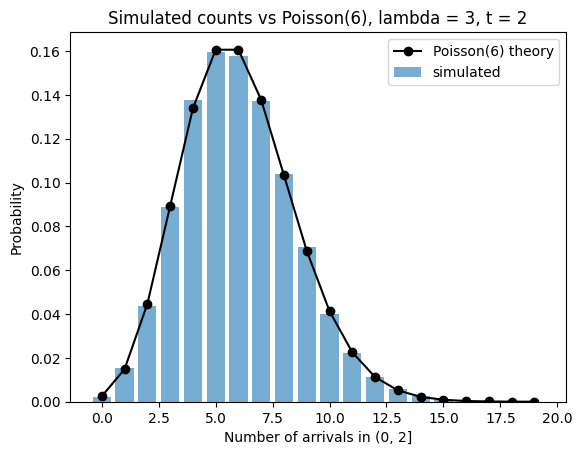

In [19]:
plt.bar(k, sim_prob, alpha=0.6, label="simulated")
plt.plot(k, theory, "ko-", label="Poisson(6) theory")
plt.xlabel("Number of arrivals in (0, 2]")
plt.ylabel("Probability")
plt.title("Simulated counts vs Poisson(6), lambda = 3, t = 2")
plt.legend()
plt.show()

In [20]:
# Validating the Independency
Event1 = Array2 >= 8
Event2 = Array3 <= 4
prob_event1 = np.mean(Event1)
prob_event2 = np.mean(Event2)
prob_e1_and_e2 = np.mean(Event1 & Event2)
print("P(A and B)   =", prob_e1_and_e2)
print("P(A) * P(B)  =", prob_event1 * prob_event2)
print("Exact theory =", stats.poisson.sf(7, 6) * stats.poisson.cdf(4, 6))

P(A and B)   = 0.07125
P(A) * P(B)  = 0.07248368749999999
Exact theory = np.float64(0.07298023349528898)


**Results from 20,000 simulated runs.**
- Mean and variance of the count in (0, 2] were 6.004 and 6.046. For (4, 6] they were 5.996 and 5.944, and for (6, 8] they were 6.003 and 5.990. The means and variances match $\lambda t = 6$, and windows at different positions give the same values, which supports stationary increments.
- The histogram of counts in (0, 2] follows the Poisson(6) probabilities closely, so the whole shape agrees with the theory and not only the mean and variance.
- The correlation between the counts in (0, 2] and (4, 6] was -0.010, which is close to zero.
- As a direct check of independence, I compared P(count in (4, 6] is at least 8 and count in (6, 8] is at most 4) with the product of the two separate probabilities. The simulated values were 0.0713 and 0.0725.
